In [1]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from phc_nzi.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from phc_nzi.mpb_configurator import *
from phc_nzi.mpi_differential_evolution import MPIdeOptimizator
from phc_nzi.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from phc_nzi.optimization_data_analyzer import OptimizationDataAnalyzer
from phc_nzi.simulation_viewer import SimulationViewer
from phc_nzi.lsf_sweeper import LSFSweeper

import phc_nzi.field_analyzer as fa
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
plt.rcParams["font.size"] = 15

T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "effective_params"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = {
    "k_points_values": [
        mp.Vector3(0.013, 0, 0),
        mp.Vector3(0.2, 0, 0),
    ],
    "k_points_label": [
        "$\Gamma$",
        "$k_x$"
    ],
}
print(k_points)

geom_2D = BaseDielectricDistribution(eps_bulk = eps).make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(eps_bulk = eps, height_slab=0.25).make_C4v_diatomic_B()

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)



configuration_options_2D = dict(
    resolution = 64,
    num_bands=12,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 100,
    extra_runner_command = "fix-hfield-phase fix-efield-phase output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z",
)


configuration_options_slab = dict(
    resolution = 64, 
    num_bands=10,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 20,
    extra_runner_command = "fix-hfield-phase fix-efield-phase output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z",
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_2D)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)


name_2D = name  + "_2D"
name_slab = name + "_slab"



data_rooth = "/work3/s232699/phc_nzi/data/"

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )


simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )




numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


3.0753321000000002
Epsilon of InP:  9.46
{'k_points_values': [Vector3<0.013, 0.0, 0.0>, Vector3<0.2, 0.0, 0.0>], 'k_points_label': ['$\\Gamma$', '$k_x$']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.25)', '(define-param r1 0.1)', '(define-param r2 0.2)']


In [2]:
r1 = 0.24
r2 = 0.23444
print("r2: ", r2)
plt.rcParams["font.size"] = 25


simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)

r2:  0.23444


K-Index: 1, Band: 4, Eps: 0.3683326688141359, Mu: 0.001655719078663843, Impedance: 0.06704605155638341, N_eff: 0.02469525110321285
K-Index: 1, Band: 6, Eps: 0.028538285577542073, Mu: 0.021341178919926502, Impedance: 0.8647593444977512, N_eff: 0.02467874912912491
K-Index: 2, Band: 4, Eps: (-0.018384566365157867+0j), Mu: (-0.04330071717447328+0j), Impedance: (1.5346906577403325-0j), N_eff: (-0.02821462224721492+0j)
K-Index: 2, Band: 6, Eps: 0.0054370590214829016, Mu: 0.14616126699104892, Impedance: 5.18482527767756, N_eff: 0.028190201050809365
K-Index: 3, Band: 4, Eps: (-0.010950309397866141+0j), Mu: (-0.09197002876808912+0j), Impedance: (2.8980773059635-0j), N_eff: (-0.0317348431592347+0j)
K-Index: 3, Band: 6, Eps: 0.004512356951425373, Mu: 0.22270118288658314, Impedance: 7.025213678241766, N_eff: 0.03170027177626285
K-Index: 4, Band: 4, Eps: (-0.010914060182568132+0j), Mu: (-0.11388898851107056+0j), Impedance: (3.2303359883386342-0j), N_eff: (-0.035256081386643566+0j)
K-Index: 4, Band:

/tmp/pbs.553074.hnode41/ipykernel_3320540/2697655441.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(k_points["k_points_label"])


[Text(-20.0, 0, '$\\Gamma$'),
 Text(0.0, 0, '$k_x$'),
 Text(20.0, 0, ''),
 Text(40.0, 0, ''),
 Text(60.0, 0, ''),
 Text(80.0, 0, ''),
 Text(100.0, 0, ''),
 Text(120.0, 0, '')]

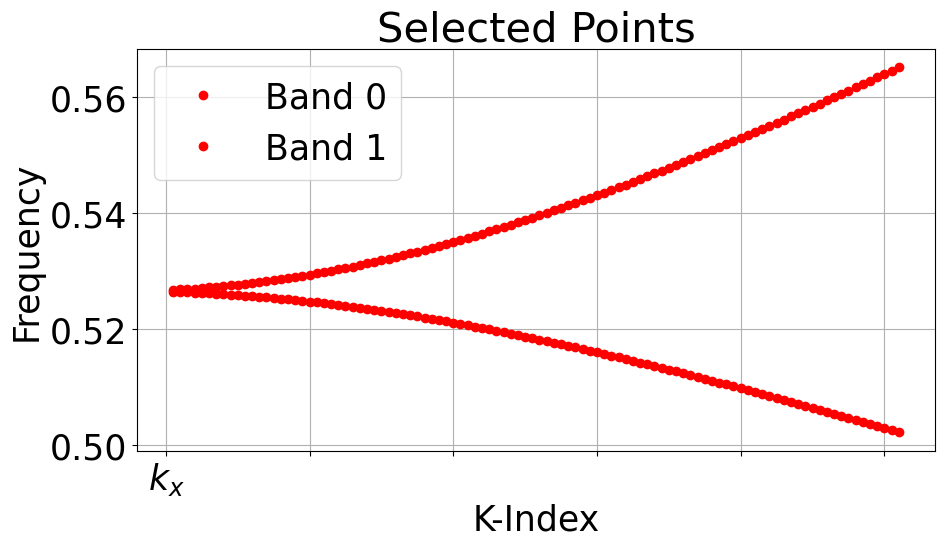

In [3]:

analyzer = fa.FieldAnalyzer(simulation_2D, [4,  6], "te", "x")
data = analyzer.get_eps_mu_impedance_neff("y", "z", plot = True)

fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.tight_layout()
ax = plt.gca()

In [9]:
print(data.keys())

Index(['k_index', 'band', 'frequency', 'eps', 'mu', 'impedance', 'n_eff',
       'kmag'],
      dtype='object')


/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


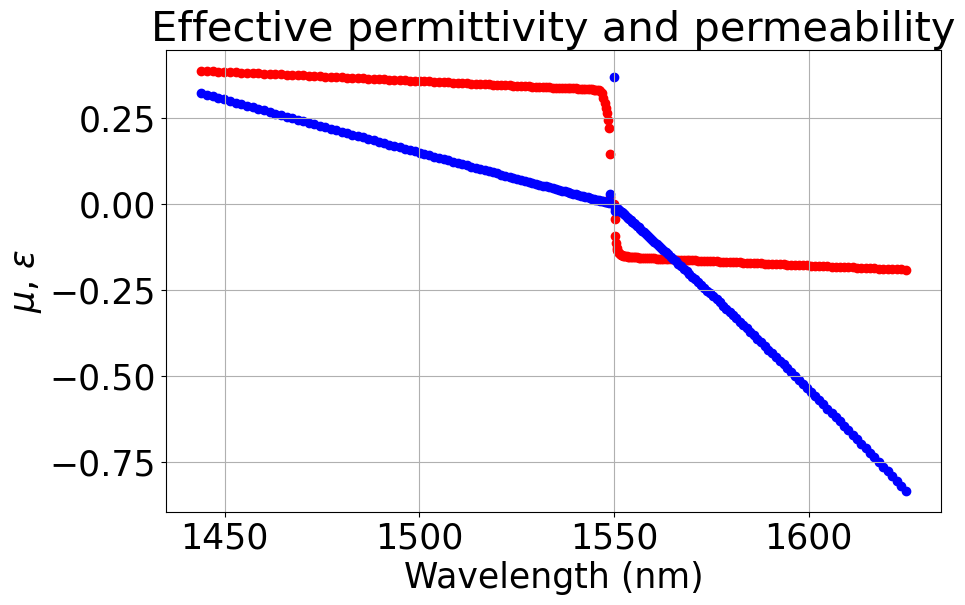

KeyError: 'neff'

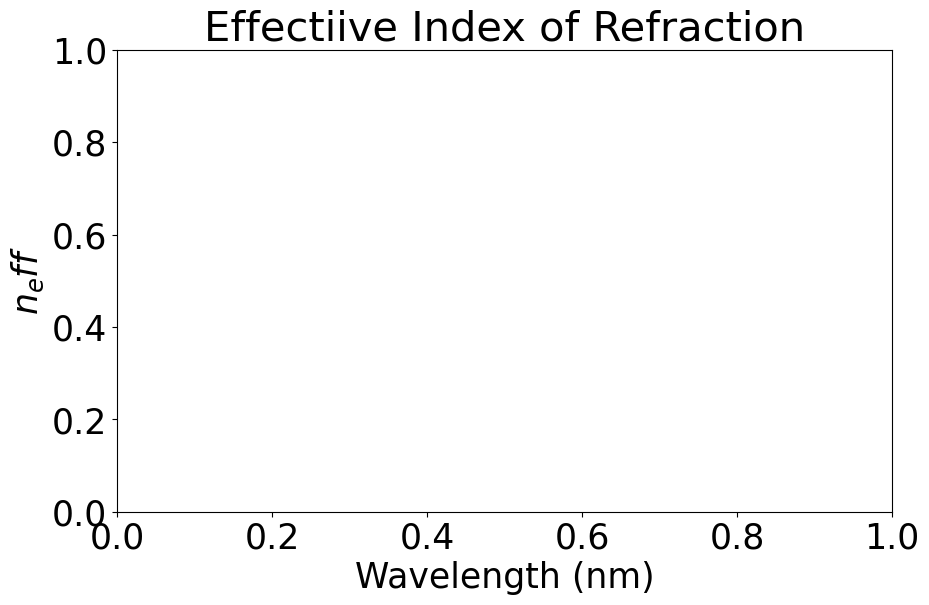

In [ ]:
plt.figure(figsize=(10, 6))


c = 3e8
a = 816e-9
f_phy = data["frequency"]*c/a
lam_phy = c/f_phy
plt.scatter(lam_phy*1e9, data["mu"], label="$\mu$", color="red")
plt.scatter(lam_phy*1e9, data["eps"], label="$\epsilon$", color="blue")
plt.grid()


plt.title("Effective permittivity and permeability")
plt.ylabel("$\mu$, $\epsilon$")
plt.xlabel("Wavelength (nm)")
plt.show()



plt.figure(figsize=(10, 6))
plt.title("Effectiive Index of Refraction")
plt.ylabel("$n_eff$")
plt.xlabel("Wavelength (nm)")
plt.plot(lam_phy*1e9, data["n_eff"], label="$n_{eff}$", color="green")

plt.figure(figsize=(10, 6))
plt.title("$Effective Impedance$")
plt.ylabel("$Z_{eff}$")
plt.xlabel("Wavelength (nm)")
plt.plot(lam_phy*1e9, data["Z_eff"], label="$Z_{eff}$", color="orange")


# plt.hlines(1/n_InP, 0, 1.5, color="red", linestyle="--", label="InP")

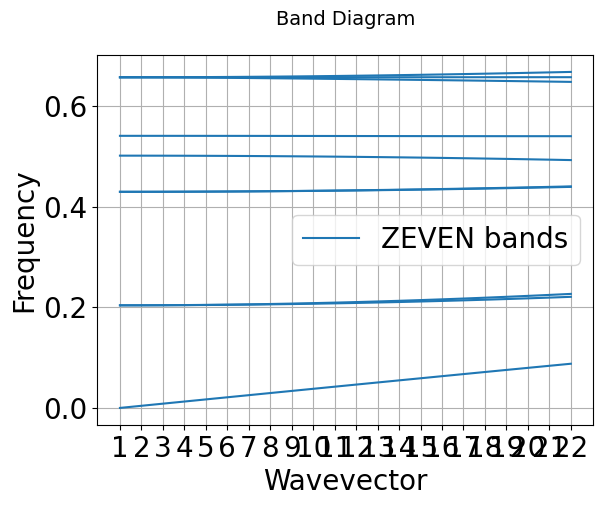

In [5]:
r1 = 0.24
r2 = 0.2390
hh=0.25
plt.rcParams["font.size"] = 20
#simulation_slab.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh), LSFOptions=lsf_config)
visualizer_slab = SimulationViewer(simulation_slab)
visualizer_slab.plot_band_diagram("zeven")

FileNotFoundError: Field file not found: /work3/s232699/phc_nzi/data/effective_params_slab/effective_params_slab-e.v.k01.b08.y.zeven.h5

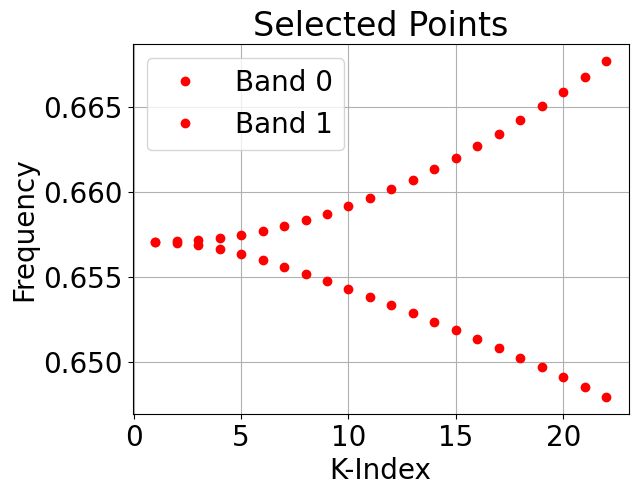

In [ ]:
import phc_nzi.field_analyzer as fa

analyzer = fa.FieldAnalyzer(simulation_slab, [8,  10], "zeven", "x")



